In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
df = pd.read_csv("data/answers1.csv")

df = df.drop(columns=df.columns[:18])
df = df.drop(["Q4_4"], axis=1)
df = df[(df['Q1'] != 'TEST' ) & (df['Q1'].notna())]

df.tail()


,Q1,Q2_1,Q2_2,Q2_3,Q3,Q4_1,Q4_2,Q4_3,Q4_5,Q4_6,Q5_1,Q5_2,Q5_3,Q5_4,Q5_5,Q6,Q7
27,301,Somewhat disagree,Strongly agree,Strongly agree,"Password strength,Building and using a passphr...",Neither agree nor disagree,Strongly agree,Somewhat disagree,Strongly agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,"Escape the cookie trap,Phishing or legit","Ja, ik had ook verwacht dat er aandacht zou zi..."
28,101,Somewhat disagree,Strongly agree,Strongly agree,"Password strength,Rejecting tracking cookies",Neither agree nor disagree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly disagree,Strongly agree,Strongly agree,Strongly agree,"Escape the cookie trap,Phishing or legit",BANGARANGA
29,406,Somewhat agree,Strongly agree,Strongly agree,"Rejecting tracking cookies,Spotting phishing e...",Strongly agree,Somewhat agree,Somewhat agree,Strongly agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Escape the cookie trap,NaN
30,313,Somewhat agree,Strongly agree,Strongly agree,"Password strength,Rejecting tracking cookies,S...",Neither agree nor disagree,Somewhat agree,Somewhat agree,Strongly agree,Strongly agree,Somewhat agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,"Spot the weakest password,Escape the cookie tr...",NaN
31,205,Somewhat agree,Somewhat agree,Somewhat agree,"Password strength,Rejecting tracking cookies,S...",Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Somewhat agree,Somewhat agree,Somewhat agree,Neither agree nor disagree,Somewhat agree,Somewhat agree,Somewhat agree,Phishing or legit,NaN


In [49]:
agreement_map = {
    "Strongly disagree": -2,
    "Somewhat disagree": -1,
    "Neither agree nor disagree": 0,
    "Somewhat agree": 1,
    "Strongly agree": 2,
}

['I feel knowledgeable about Data Privacy', 'I want to know more about Data Privacy', 'I think Data Privacy is important']


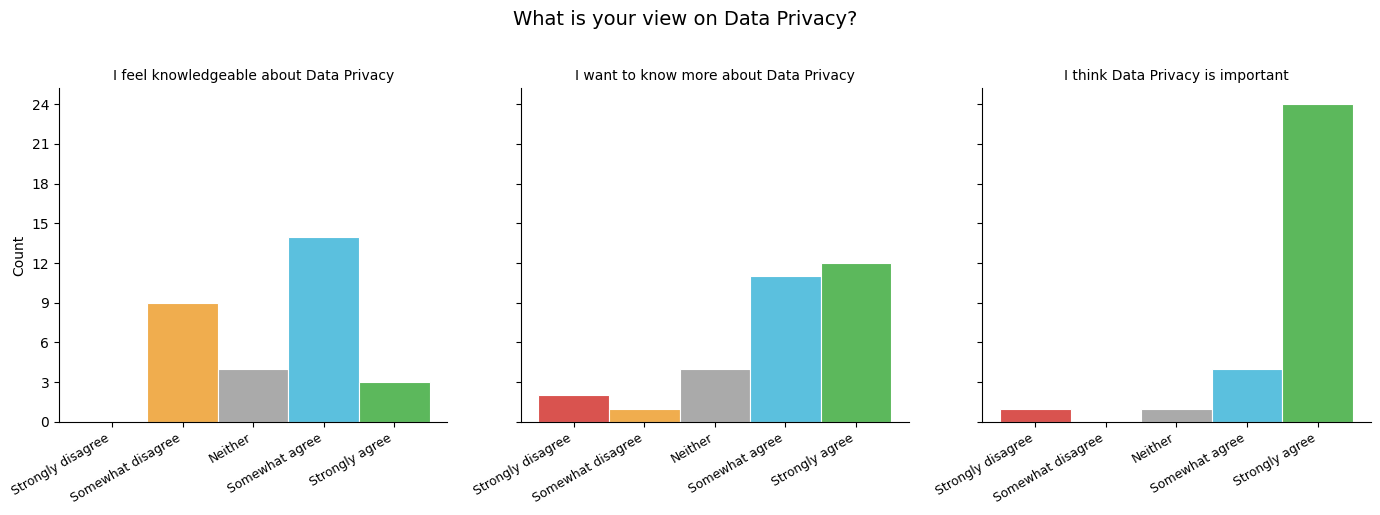

In [50]:
# Q2
Q2s = []
Q2n = []
for i in range(3):
    title = df[f"Q2_{i+1}"][0]
    Q2s.append(title.replace("What is your view on Data Privacy? - ", ""))
    vals = df[f"Q2_{i+1}"][2:]
    Q2n.append(vals.map(agreement_map))

print(Q2s)

fig, ax = plt.subplots(1, 3, sharey=True, figsize=(14, 5))
fig.suptitle("What is your view on Data Privacy?", fontsize=14, y=1.02)

colors = ["#d9534f" , "#f0ad4e", "#aaaaaa", "#5bc0de", "#5cb85c"]
labels = ["Strongly disagree", "Somewhat disagree", "Neither", "Somewhat agree", "Strongly agree"]
bins = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]

for i, vals in enumerate(Q2n):
    counts, _, patches = ax[i].hist(vals, bins=bins, edgecolor="white", linewidth=0.8)
    for patch, color in zip(patches, colors):
        patch.set_facecolor(color)
    ax[i].set_xticks([-2, -1, 0, 1, 2], labels, rotation=30, ha="right", fontsize=9)
    ax[i].set_title(Q2s[i], fontsize=10, wrap=True)
    ax[i].spines[["top", "right"]].set_visible(False)
    ax[i].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

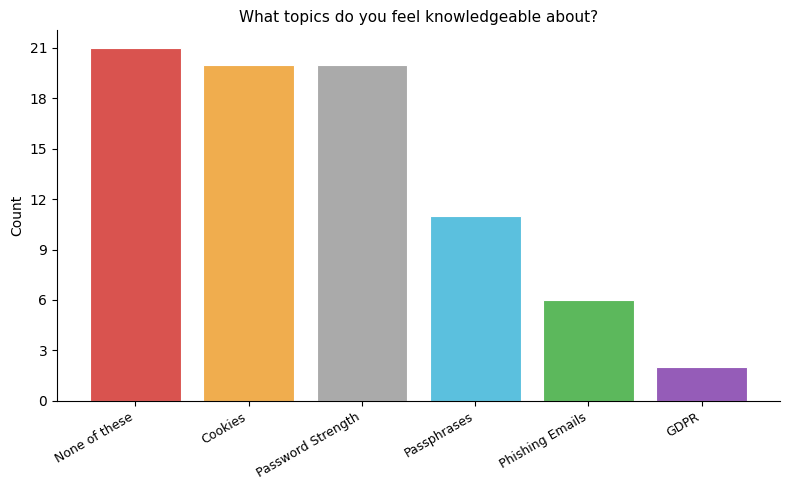

In [51]:
# Q3
Q3 = df["Q3"][0]
Q3_vals = df["Q3"][2:].dropna().str.split(",").explode().str.strip()
colors = ["#d9534f" , "#f0ad4e", "#aaaaaa", "#5bc0de", "#5cb85c",  "#955cb8"]
labels = ["None of these", "Cookies", "Password Strength", "Passphrases", "Phishing Emails", "GDPR"]
bins = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]

label_map = {
    "None of these": "None",
    "Rejecting tracking cookies": "Cookies",
    "Password strength": "Password Strength",
    "Building and using a passphrase": "Passphrases",
    "Spotting phishing emails": "Phishing Emails",
    "Basic information about the GDPR (General Data Protection Regulation)": "GDPR"
}

label_counts = Q3_vals.value_counts().rename(index=label_map)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, label_counts, color=colors, edgecolor="white", linewidth=0.8)
ax.set_title(Q3, fontsize=11, wrap=True)
ax.set_ylabel("Count")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


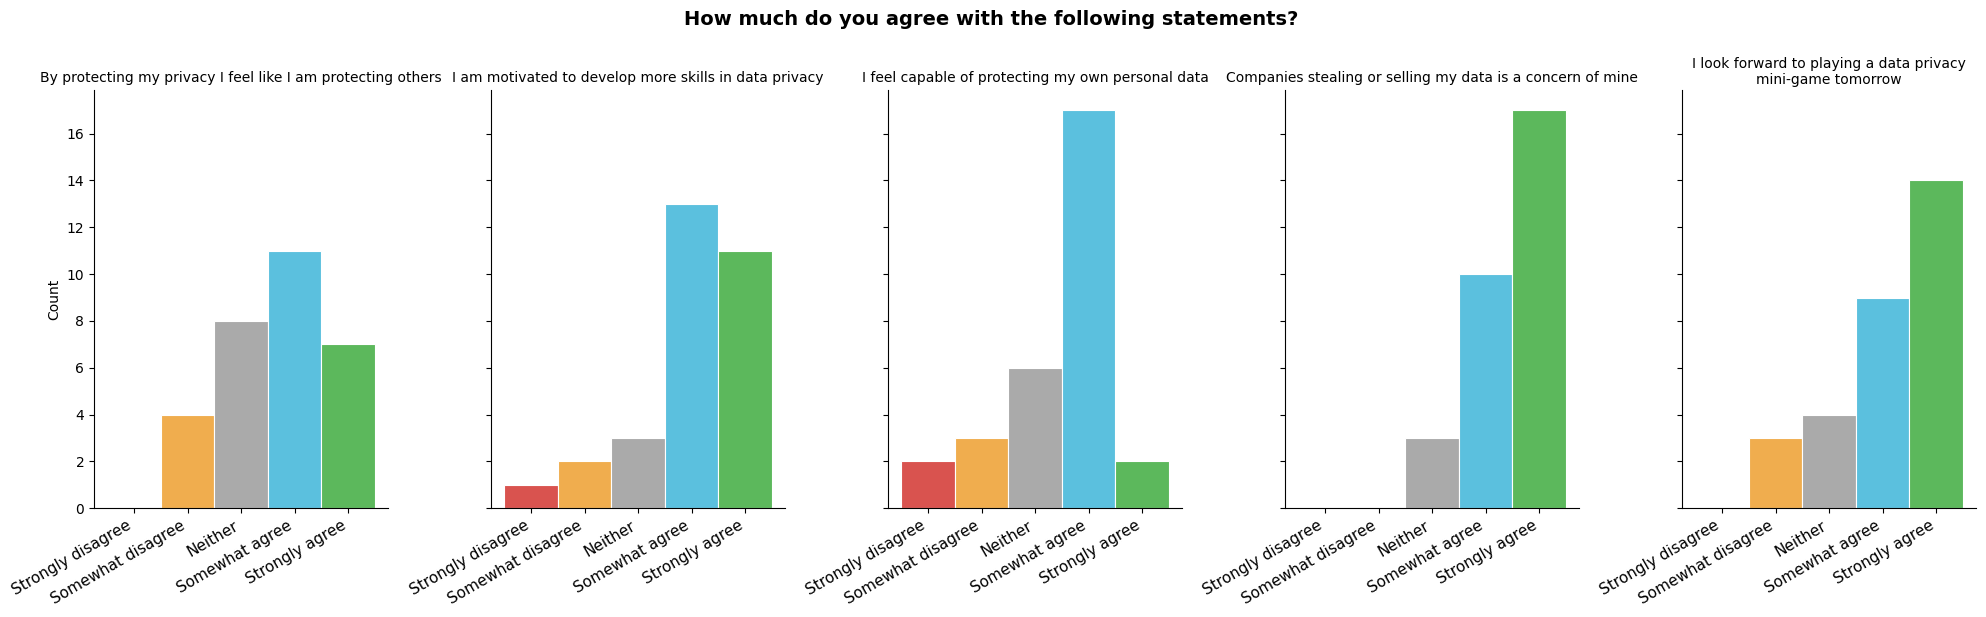

In [52]:
# Q4
Q4s = []
Q4n = []
for i in range(6):
    col = f"Q4_{i+1}"
    if col not in df.columns:
        # was control
        continue
    Q4s.append(df[col][0].replace("How much do you agree with the following statements? - ", ""))
    Q4n.append(df[col][2:].map(agreement_map))

fig, ax = plt.subplots(1, 5, sharey=True, figsize=(20, 6))
ax = ax.flatten()
fig.suptitle("How much do you agree with the following statements?", fontsize=14, fontweight="bold", y=1.02)
colors = ["#d9534f", "#f0ad4e", "#aaaaaa", "#5bc0de", "#5cb85c"]
labels = ["Strongly disagree", "Somewhat disagree", "Neither", "Somewhat agree", "Strongly agree"]
bins = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]

for i, vals in enumerate(Q4n):
    counts, _, patches = ax[i].hist(vals, bins=bins, edgecolor="white", linewidth=0.8)
    for patch, color in zip(patches, colors):
        patch.set_facecolor(color)
    ax[i].set_xticks([-2, -1, 0, 1, 2], labels, rotation=30, ha="right", fontsize=11)
    ax[i].set_title(Q4s[i], fontsize=10, wrap=True)
    ax[i].spines[["top", "right"]].set_visible(False)
    ax[i].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

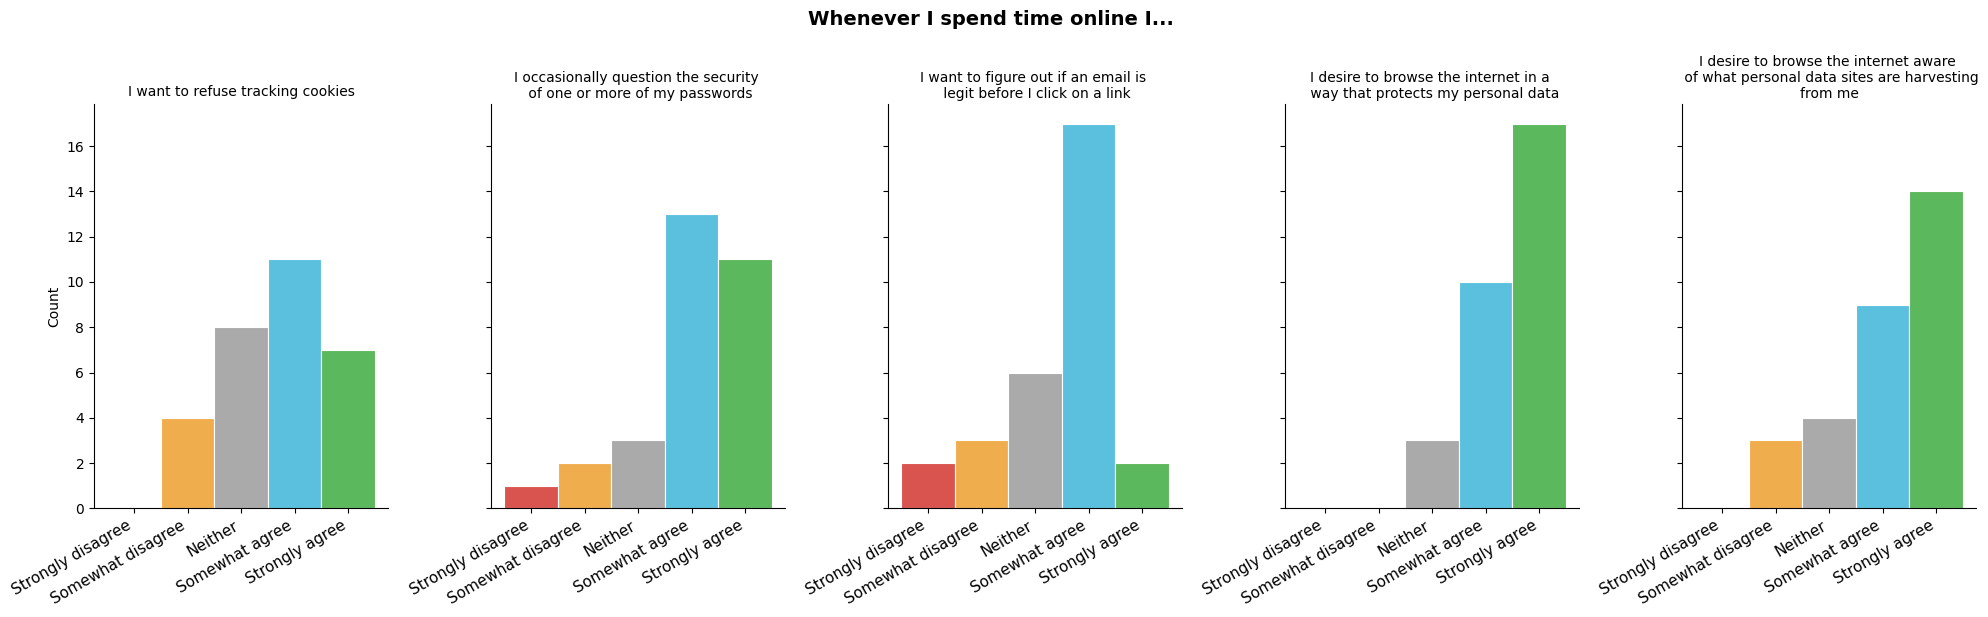

In [53]:
# Q5
Q5s = []
Q5n = []

subtitle = [
    "I want to refuse tracking cookies",
    "I occasionally question the security \n of one or more of my passwords",
    "I want to figure out if an email is \n legit before I click on a link",
    "I desire to browse the internet in a \n way that protects my personal data",
    "I desire to browse the internet aware \n of what personal data sites are harvesting from me",
]

for i in range(5):
    col = f"Q5_{i+1}"
    Q5s.append(subtitle[i])
    Q5n.append(df[col][2:].map(agreement_map))

fig, ax = plt.subplots(1, 5, sharey=True, figsize=(20, 6))
ax = ax.flatten()
fig.suptitle("Whenever I spend time online I...", fontsize=14, fontweight="bold", y=1.02)
colors = ["#d9534f", "#f0ad4e", "#aaaaaa", "#5bc0de", "#5cb85c"]
labels = ["Strongly disagree", "Somewhat disagree", "Neither", "Somewhat agree", "Strongly agree"]
bins = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]

for i, vals in enumerate(Q4n):
    counts, _, patches = ax[i].hist(vals, bins=bins, edgecolor="white", linewidth=0.8)
    for patch, color in zip(patches, colors):
        patch.set_facecolor(color)
    ax[i].set_xticks([-2, -1, 0, 1, 2], labels, rotation=30, ha="right", fontsize=11)
    ax[i].set_title(Q5s[i], fontsize=10, wrap=True)
    ax[i].spines[["top", "right"]].set_visible(False)
    ax[i].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

In [54]:
# Q6 maybe not useful for now